# Vision Transformer (ViT-B16) - Skin Lesion Classification (Task 1: Melanoma vs Keratosis & Nevus)
Google Colab Pro Optimized Implementation in PyTorch (A100 / T4 GPU Accelerated)

In [ ]:
# 1. Mount Google Drive, set directories, and extract Task 1 dataset
from google.colab import drive
import os, sys, subprocess

drive.mount('/content/drive')

# Set path to dissertation folder on Google Drive
drive_path = '/content/drive/MyDrive/MSc AI/dissertation'
if os.path.exists(drive_path):
    os.chdir(drive_path)
    if drive_path not in sys.path:
        sys.path.insert(0, drive_path)

# Define model save directory on Google Drive
SAVE_DIR = os.path.join(drive_path, 'saved_models') if os.path.exists(drive_path) else './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Current Working Directory: {os.getcwd()}")
print(f"Model Save Directory: {SAVE_DIR}")

# Unzip ONLY dataset/task1/* to Colab local SSD storage (/content) for maximum speed
zip_path = os.path.join(drive_path, 'dataset.zip') if os.path.exists(os.path.join(drive_path, 'dataset.zip')) else 'dataset.zip'
extract_dir = '/content' if os.path.exists('/content') else '.'
target_train_check = os.path.join(extract_dir, 'dataset', 'task1', 'train')

if os.path.exists(zip_path):
    if not os.path.exists(target_train_check):
        print(f"Unzipping Task 1 from {zip_path} to local Colab SSD...")
        # Extract ONLY dataset/task1/* pattern using quiet (-q) unzip
        ret = os.system(f'unzip -q "{zip_path}" "dataset/task1/*" -d "{extract_dir}"')
        if ret != 0:
            import zipfile
            print("Native unzip failed, falling back to Python zipfile for Task 1...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                task1_members = [m for m in zip_ref.namelist() if m.startswith('dataset/task1/')]
                zip_ref.extractall(extract_dir, members=task1_members)
        print("Task 1 Dataset unzipped successfully!")
    else:
        print(f"Task 1 Dataset already extracted at {target_train_check}")
else:
    print(f"Warning: {zip_path} not found. Please ensure dataset.zip is uploaded to dissertation folder.")


Mounted at /content/drive
Current Working Directory: /content/drive/MyDrive/MSc AI/dissertation
Model Save Directory: /content/drive/MyDrive/MSc AI/dissertation/saved_models
Unzipping Task 1 from /content/drive/MyDrive/MSc AI/dissertation/dataset.zip to local Colab SSD...
Task 1 Dataset unzipped successfully!


In [ ]:
# 2. Install Required PyTorch Packages
!pip install -q torch torchvision timm scikit-learn matplotlib pandas seaborn tqdm

In [ ]:
# 3. Imports and Configuration
import os, sys, warnings, logging
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN_WARNING'] = '1'
warnings.filterwarnings('ignore')
for logger_name in ['huggingface_hub', 'huggingface_hub.utils._http', 'huggingface_hub.file_download', 'timm']:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Enable cuDNN benchmark for faster convolutions & matrix multiplications on GPU
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

class CONFIG:
    HEIGHT = 224
    WIDTH = 224
    SEED = 42
    FOLDS = 5
    BATCH_SIZE = [32] * FOLDS  # Increased to 32 for Colab Pro GPUs (A100 / T4)
    EPOCHS = [15] * FOLDS
    NUM_WORKERS = 4           # Multi-threaded DataLoader for Colab Pro CPU
    PIN_MEMORY = True          # Fast host-to-device memory transfer
    LABEL_SMOOTHING = 0.05     # Matches dissertation Sections 3.5 & 3.7.3
    USE_AMP = True             # Automatic Mixed Precision (FP16 / BF16)
    VERBOSE = 1


In [ ]:
# 4. PyTorch Transforms & Transfer Model Architecture
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def get_transforms(augment=False, dim=224):
    if augment:
        return transforms.Compose([
            transforms.Resize((dim, dim)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            # RandomAffine implements Shear, Zoom/Scale, Translation/Shift, and Rotation (matching Section 3.3)
            transforms.RandomAffine(
                degrees=180,
                translate=(0.1, 0.1),   # width_shift & height_shift
                scale=(0.85, 1.15),     # zoom_range
                shear=15                # shear_range
            ),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((dim, dim)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        ])

class TransferModel(nn.Module):
    def __init__(self, base_model, num_features, num_classes=1):
        super(TransferModel, self).__init__()
        self.base_model = base_model
        self.bn1 = nn.BatchNorm1d(num_features)
        self.fc1 = nn.Linear(num_features, 32)
        self.gelu = nn.GELU()
        self.bn2 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        features = self.base_model(x)
        if isinstance(features, (list, tuple)):
            features = features[-1]
        features = features.view(features.size(0), -1)
        x = self.bn1(features)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.bn2(x)
        x = self.fc2(x)
        return x

def build_model(dim=224):
    base_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
    model = TransferModel(base_vit, num_features=768)
    return model


In [ ]:
# 5. Training & Evaluation Helper Functions (Colab Pro AMP Accelerated)
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, scheduler=None, label_smoothing=0.05, use_amp=True):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    amp_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

    for images, targets in dataloader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).float()
        if targets.ndim == 1:
            targets = targets.unsqueeze(1)

        # Apply Label Smoothing (Section 3.5 & 3.7.3 in dissertation)
        if label_smoothing > 0:
            targets_smoothed = targets * (1.0 - label_smoothing) + 0.5 * label_smoothing
        else:
            targets_smoothed = targets

        optimizer.zero_grad()

        if use_amp and device.type == 'cuda':
            with torch.cuda.amp.autocast(dtype=amp_dtype):
                outputs = model(images)
                loss = criterion(outputs, targets_smoothed)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, targets_smoothed)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * images.size(0)
        # Cast float16 / bfloat16 to float32 before converting to NumPy to prevent BFloat16 TypeError
        probs = torch.sigmoid(outputs).detach().cpu().float().numpy()
        all_preds.extend(probs)
        all_targets.extend(targets.cpu().float().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    acc = ((np.array(all_preds) >= 0.5).astype(int).ravel() == np.array(all_targets).ravel()).mean()
    try:
        auc_val = roc_auc_score(all_targets, all_preds)
    except Exception:
        auc_val = 0.5
    return {'loss': epoch_loss, 'accuracy': acc, 'auc': auc_val}

def evaluate_model(model, dataloader, criterion, device, use_amp=True):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    amp_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).float()
            if targets.ndim == 1:
                targets = targets.unsqueeze(1)

            if use_amp and device.type == 'cuda':
                with torch.cuda.amp.autocast(dtype=amp_dtype):
                    outputs = model(images)
                    loss = criterion(outputs, targets)
            else:
                outputs = model(images)
                loss = criterion(outputs, targets)

            running_loss += loss.item() * images.size(0)
            # Cast float16 / bfloat16 to float32 before converting to NumPy
            probs = torch.sigmoid(outputs).detach().cpu().float().numpy()
            all_preds.extend(probs)
            all_targets.extend(targets.cpu().float().numpy())

    eval_loss = running_loss / max(len(dataloader.dataset), 1)
    acc = ((np.array(all_preds) >= 0.5).astype(int).ravel() == np.array(all_targets).ravel()).mean()
    try:
        auc_val = roc_auc_score(all_targets, all_preds)
    except Exception:
        auc_val = 0.5
    return {'loss': eval_loss, 'accuracy': acc, 'auc': auc_val}, np.array(all_targets), np.array(all_preds)

def test_evaluate(model, test_loader, device=None, threshold=0.5):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probs = torch.sigmoid(outputs).detach().cpu().float().numpy().flatten()
            all_preds.extend(probs)
            all_targets.extend(labels.cpu().float().numpy().flatten())

    predictions = np.array(all_preds)
    y_test = np.array(all_targets)

    # Search for optimal decision threshold maximizing Macro F1-score
    best_thresh = threshold
    best_macro_f1 = 0.0
    for t in np.arange(0.20, 0.80, 0.05):
        t_labels = (predictions >= t).astype(int)
        rep = classification_report(y_test, t_labels, output_dict=True, zero_division=0)
        macro_f1 = rep['macro avg']['f1-score']
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_thresh = t

    eval_thresholds = [0.5] if abs(best_thresh - 0.5) < 1e-4 else [0.5, best_thresh]
    for current_t in eval_thresholds:
        predicted_labels = (predictions >= current_t).astype(int)
        report = classification_report(y_test, predicted_labels, target_names=['Class 0', 'Class 1'], output_dict=True, zero_division=0)
        try:
            roc = roc_auc_score(y_test, predictions)
        except Exception:
            roc = 0.5

        print(f"\n--- Classification Metrics (Decision Threshold = {current_t:.2f}) ---")
        print(f"ROC AUC Score: {roc:.6f}")
        cm = confusion_matrix(y_test, predicted_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
        disp.plot(cmap=plt.cm.Blues)
        plt.show()

        class_0 = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
        class_1 = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
        metrics_data = {
            'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
            'Class 0': [class_0['precision'], class_0['recall'], class_0['f1-score'], class_0['support']],
            'Class 1': [class_1['precision'], class_1['recall'], class_1['f1-score'], class_1['support']],
            'Accuracy': [report['accuracy'], '', '', ''],
            'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
            'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
            'ROC-AUC-Score': [roc, '', '', '']
        }
        df_metrics = pd.DataFrame(metrics_data)
        print(df_metrics.to_string(index=False))

def test_evaluate_ensemble(models, test_loader, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    all_fold_probs = []
    all_targets = []

    for fold_idx, model in enumerate(models):
        model.to(device)
        model.eval()
        fold_preds = []
        targets = []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=True)
                outputs = model(images)
                probs = torch.sigmoid(outputs).detach().cpu().float().numpy().flatten()
                fold_preds.extend(probs)
                if len(all_targets) < len(test_loader.dataset):
                    targets.extend(labels.cpu().float().numpy().flatten())
        all_fold_probs.append(fold_preds)
        if len(all_targets) == 0:
            all_targets = targets

    # Average predicted probabilities across all 5 trained fold models
    ensemble_preds = np.mean(all_fold_probs, axis=0)
    y_test = np.array(all_targets)

    print(f"\n=================== 5-FOLD ENSEMBLE TEST EVALUATION (TASK 1) ===================")
    roc = roc_auc_score(y_test, ensemble_preds)
    print(f"Ensemble ROC AUC Score: {roc:.6f}")

    predicted_labels = (ensemble_preds >= 0.5).astype(int)
    report = classification_report(y_test, predicted_labels, target_names=['Class 0', 'Class 1'], output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0 (Nevus/Keratosis)', 'Class 1 (Melanoma)'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("5-Fold Ensemble Confusion Matrix (Task 1)")
    plt.show()

    class_0 = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_1 = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    metrics_data = {
        'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
        'Class 0': [class_0['precision'], class_0['recall'], class_0['f1-score'], class_0['support']],
        'Class 1': [class_1['precision'], class_1['recall'], class_1['f1-score'], class_1['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }
    df_metrics = pd.DataFrame(metrics_data)
    print(df_metrics.to_string(index=False))


In [ ]:
# 6. 5-Fold Stratified Cross-Validation Training Loop (AMP + OneCycleLR Scheduler)
TRAIN_DIR = '/content/dataset/task1/train'
if not os.path.exists(TRAIN_DIR):
    TRAIN_DIR = 'dataset/task1/train'
if not os.path.exists(TRAIN_DIR):
    TRAIN_DIR = '/content/drive/MyDrive/MSc AI/dissertation/dataset/task1/train'

transform = get_transforms(augment=True, dim=CONFIG.HEIGHT)
train_data = ImageFolder(root=TRAIN_DIR, transform=transform)
print(f"Loaded Training Dataset from {TRAIN_DIR} ({len(train_data)} samples)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

targets = [s[1] for s in train_data.samples]
skf = StratifiedKFold(n_splits=CONFIG.FOLDS, shuffle=True, random_state=CONFIG.SEED)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n___________________________FOLD {fold+1}__________________________\n")
    train_sub = Subset(train_data, train_idx)
    val_sub = Subset(train_data, val_idx)

    sub_targets = [targets[i] for i in train_idx]
    class_counts = np.bincount(sub_targets)
    class_weights = 1.0 / np.maximum(class_counts, 1)
    sample_weights = torch.from_numpy(np.array([class_weights[t] for t in sub_targets])).double()
    sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_sub,
        batch_size=CONFIG.BATCH_SIZE[fold],
        sampler=sampler,
        num_workers=CONFIG.NUM_WORKERS,
        pin_memory=CONFIG.PIN_MEMORY,
        persistent_workers=True if CONFIG.NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        val_sub,
        batch_size=CONFIG.BATCH_SIZE[fold],
        shuffle=False,
        num_workers=CONFIG.NUM_WORKERS,
        pin_memory=CONFIG.PIN_MEMORY,
        persistent_workers=True if CONFIG.NUM_WORKERS > 0 else False
    )

    model = build_model(CONFIG.HEIGHT).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG.USE_AMP)

    # Learning Rate Scheduler (Section 3.7.4: Warmup starting at 5e-6 -> Linear Ramp-up -> Cosine Decay)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-4,
        steps_per_epoch=len(train_loader),
        epochs=CONFIG.EPOCHS[fold],
        pct_start=0.2,       # 20% warmup phase
        div_factor=20.0,      # Initial LR = 1e-4 / 20 = 5e-6
        final_div_factor=1e4
    )

    best_val_auc = 0.0

    for epoch in range(CONFIG.EPOCHS[fold]):
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            scheduler=scheduler, label_smoothing=CONFIG.LABEL_SMOOTHING, use_amp=CONFIG.USE_AMP
        )
        val_metrics, val_targets, val_preds = evaluate_model(model, val_loader, criterion, device, use_amp=CONFIG.USE_AMP)
        print(
            f"Epoch {epoch+1:02d}/{CONFIG.EPOCHS[fold]:02d} | "
            f"Train Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['accuracy']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val AUC: {val_metrics['auc']:.4f}"
        )
        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            save_path = os.path.join(SAVE_DIR, f'model-fold-{fold+1}.pt')
            torch.save(model.state_dict(), save_path)
            print(f" Saved best model weights for Fold {fold+1} to {save_path}")
    print(f"#### FOLD {fold+1} Best Val AUC = {best_val_auc:.4f}")


Loaded Training Dataset from /content/dataset/task1/train (2000 samples)
Using compute device: cuda

___________________________FOLD 1__________________________

Epoch 01/15 | Train Loss: 0.6337 | Acc: 0.6350 | Val Loss: 0.5648 | Val Acc: 0.7050 | Val AUC: 0.7117
 Saved best model weights for Fold 1 to /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-1.pt
Epoch 02/15 | Train Loss: 0.5495 | Acc: 0.7325 | Val Loss: 0.5112 | Val Acc: 0.7425 | Val AUC: 0.7607
 Saved best model weights for Fold 1 to /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-1.pt
Epoch 03/15 | Train Loss: 0.5048 | Acc: 0.7669 | Val Loss: 0.7448 | Val Acc: 0.5525 | Val AUC: 0.7747
 Saved best model weights for Fold 1 to /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-1.pt
Epoch 04/15 | Train Loss: 0.4843 | Acc: 0.7775 | Val Loss: 0.7805 | Val Acc: 0.6050 | Val AUC: 0.7574
Epoch 05/15 | Train Loss: 0.4328 | Acc: 0.8194 | Val Loss: 0.4301 | Val Acc: 0.8300 | Val AUC:

Loaded Test Dataset from /content/dataset/task1/test (600 samples)

______________________ ENACTING EVALUATION FOLD 1 ______________________

Loading checkpoint from: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-1.pt

--- Classification Metrics (Decision Threshold = 0.50) ---
ROC AUC Score: 0.816337


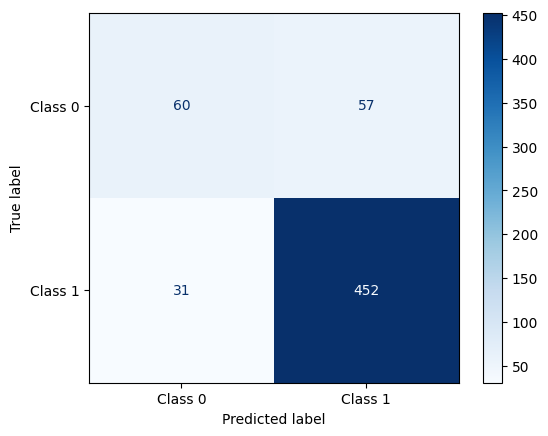

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.659341   0.888016  0.853333  0.773678     0.843424      0.816337
   Recall   0.512821   0.935818            0.724319     0.853333              
 F1-Score   0.576923   0.911290            0.744107     0.846089              
  Support 117.000000 483.000000                                               

--- Classification Metrics (Decision Threshold = 0.70) ---
ROC AUC Score: 0.816337


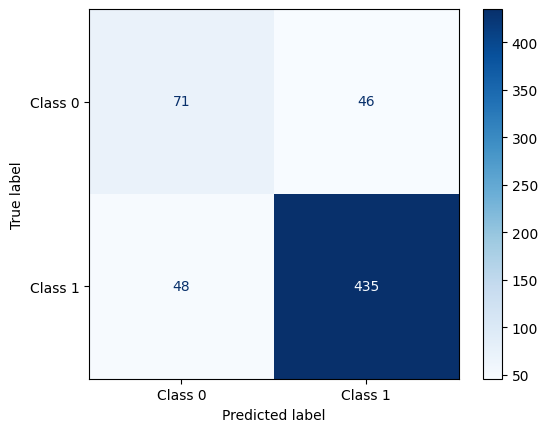

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.596639   0.904366  0.843333  0.750502     0.844359      0.816337
   Recall   0.606838   0.900621            0.753729     0.843333              
 F1-Score   0.601695   0.902490            0.752092     0.843835              
  Support 117.000000 483.000000                                               

______________________ ENACTING EVALUATION FOLD 2 ______________________

Loading checkpoint from: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-2.pt

--- Classification Metrics (Decision Threshold = 0.50) ---
ROC AUC Score: 0.808055


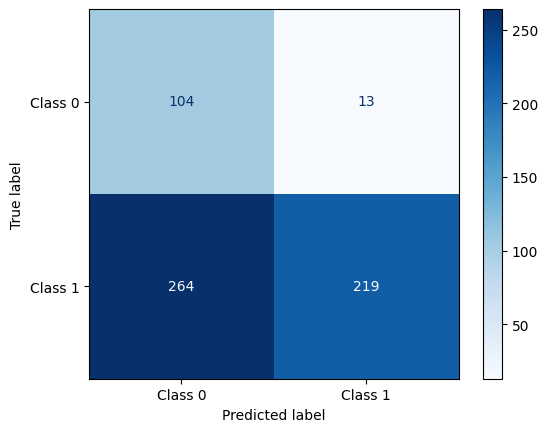

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.282609   0.943966  0.538333  0.613287     0.815001      0.808055
   Recall   0.888889   0.453416            0.671153     0.538333              
 F1-Score   0.428866   0.612587            0.520727     0.576762              
  Support 117.000000 483.000000                                               

--- Classification Metrics (Decision Threshold = 0.20) ---
ROC AUC Score: 0.808055


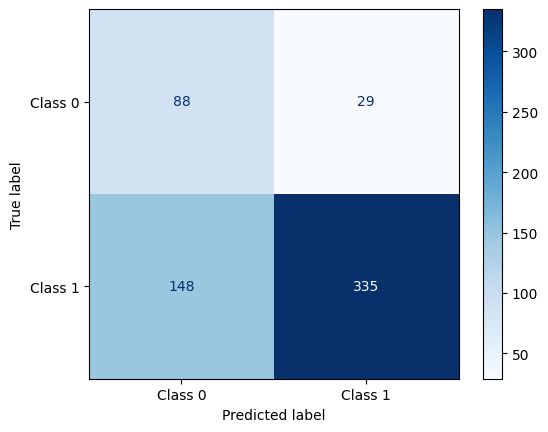

   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.372881   0.920330    0.705  0.646606     0.813577      0.808055
   Recall   0.752137   0.693582           0.722859        0.705              
 F1-Score   0.498584   0.791027           0.644805     0.734001              
  Support 117.000000 483.000000                                              

______________________ ENACTING EVALUATION FOLD 3 ______________________

Loading checkpoint from: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-3.pt

--- Classification Metrics (Decision Threshold = 0.50) ---
ROC AUC Score: 0.843057


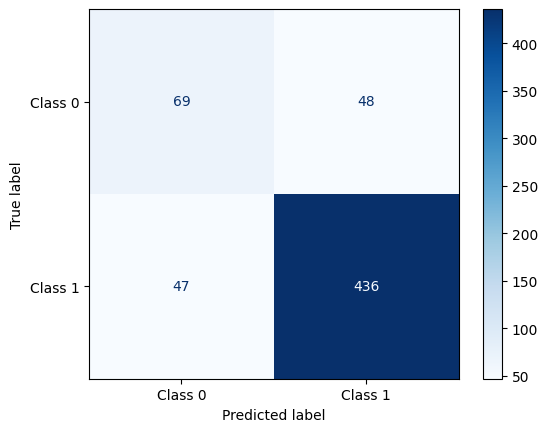

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.594828   0.900826  0.841667  0.747827     0.841157      0.843057
   Recall   0.589744   0.902692            0.746218     0.841667              
 F1-Score   0.592275   0.901758            0.747016     0.841409              
  Support 117.000000 483.000000                                               

--- Classification Metrics (Decision Threshold = 0.45) ---
ROC AUC Score: 0.843057


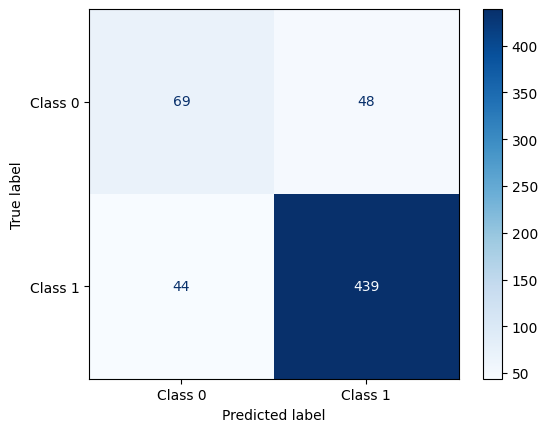

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.610619   0.901437  0.846667  0.756028     0.844728      0.843057
   Recall   0.589744   0.908903            0.749323     0.846667              
 F1-Score   0.600000   0.905155            0.752577     0.845649              
  Support 117.000000 483.000000                                               

______________________ ENACTING EVALUATION FOLD 4 ______________________

Loading checkpoint from: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-4.pt

--- Classification Metrics (Decision Threshold = 0.50) ---
ROC AUC Score: 0.837430


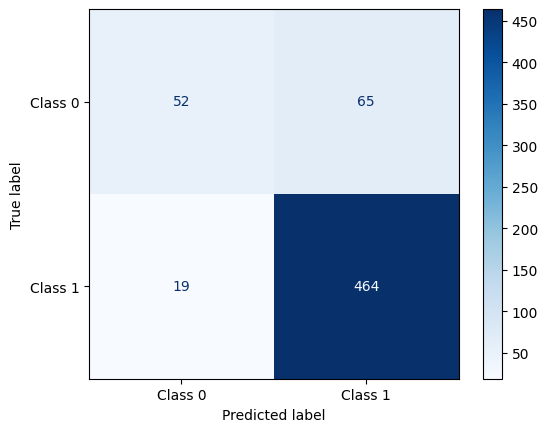

   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.732394   0.877127     0.86  0.804761     0.848904       0.83743
   Recall   0.444444   0.960663           0.702553         0.86              
 F1-Score   0.553191   0.916996           0.735094     0.846054              
  Support 117.000000 483.000000                                              

--- Classification Metrics (Decision Threshold = 0.75) ---
ROC AUC Score: 0.837430


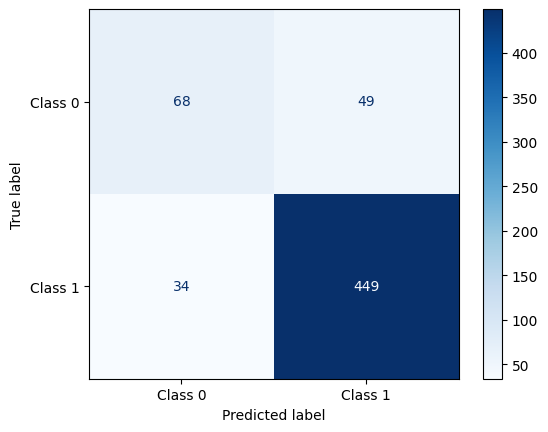

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.666667   0.901606  0.861667  0.784137     0.855793       0.83743
   Recall   0.581197   0.929607            0.755402     0.861667              
 F1-Score   0.621005   0.915392            0.768199     0.857987              
  Support 117.000000 483.000000                                               

______________________ ENACTING EVALUATION FOLD 5 ______________________

Loading checkpoint from: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-5.pt

--- Classification Metrics (Decision Threshold = 0.50) ---
ROC AUC Score: 0.845021


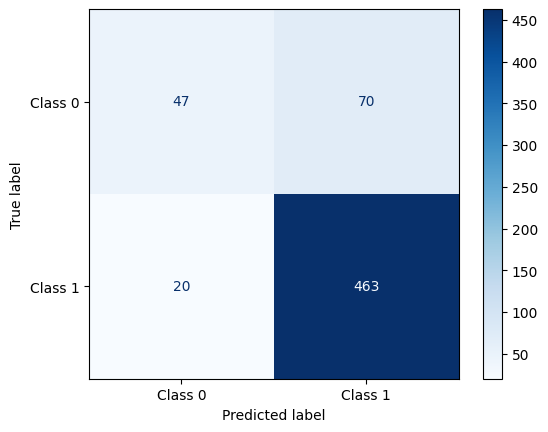

   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.701493   0.868668     0.85   0.78508     0.836069      0.845021
   Recall   0.401709   0.958592           0.680151         0.85              
 F1-Score   0.510870   0.911417           0.711143     0.833311              
  Support 117.000000 483.000000                                              

--- Classification Metrics (Decision Threshold = 0.75) ---
ROC AUC Score: 0.845021


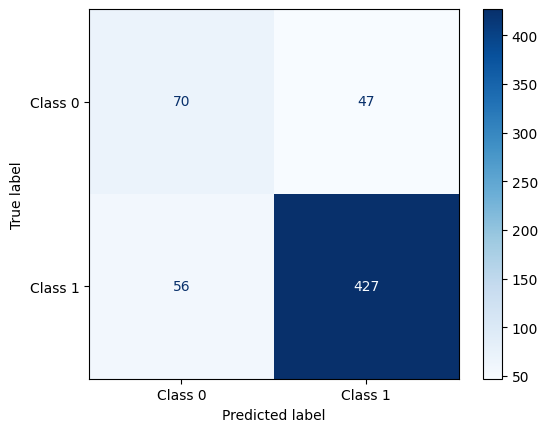

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.555556   0.900844  0.828333    0.7282     0.833513      0.845021
   Recall   0.598291   0.884058            0.741174     0.828333              
 F1-Score   0.576132   0.892372            0.734252     0.830705              
  Support 117.000000 483.000000                                               

=================== 5-FOLD ENSEMBLE TEST EVALUATION (TASK 1) ===================
Ensemble ROC AUC Score: 0.863655


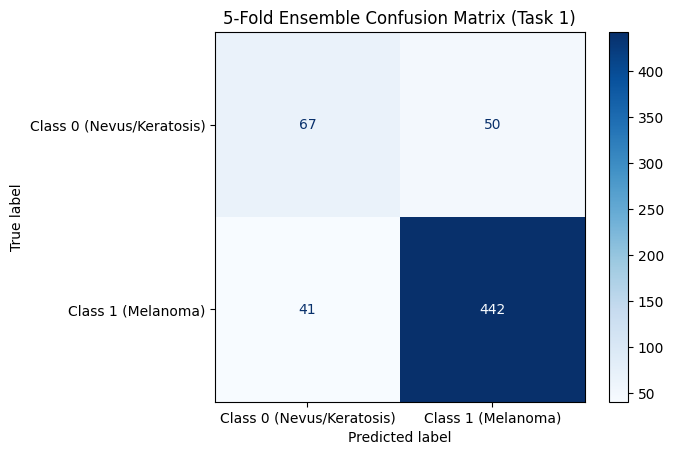

   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.620370   0.898374  0.848333  0.759372     0.844163      0.863655
   Recall   0.572650   0.915114            0.743882     0.848333              
 F1-Score   0.595556   0.906667            0.751111        0.846              
  Support 117.000000 483.000000                                               


In [ ]:
# 7. Test Evaluation & 5-Fold Ensemble Evaluation
TEST_DIR = '/content/dataset/task1/test'
if not os.path.exists(TEST_DIR):
    TEST_DIR = 'dataset/task1/test'
if not os.path.exists(TEST_DIR):
    TEST_DIR = '/content/drive/MyDrive/MSc AI/dissertation/dataset/task1/test'

test_transform = get_transforms(augment=False, dim=CONFIG.HEIGHT)
test_data = ImageFolder(root=TEST_DIR, transform=test_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=CONFIG.NUM_WORKERS, pin_memory=CONFIG.PIN_MEMORY)
print(f"Loaded Test Dataset from {TEST_DIR} ({len(test_data)} samples)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'SAVE_DIR' not in globals():
    SAVE_DIR = '/content/drive/MyDrive/MSc AI/dissertation/saved_models' if os.path.exists('/content/drive/MyDrive/MSc AI/dissertation') else './saved_models'

trained_models = []
for fold in range(CONFIG.FOLDS):
    checkpoint_path = os.path.join(SAVE_DIR, f'model-fold-{fold+1}.pt') if 'SAVE_DIR' in globals() and os.path.exists(os.path.join(SAVE_DIR, f'model-fold-{fold+1}.pt')) else f'model-fold-{fold+1}.pt'
    if os.path.exists(checkpoint_path):
        print(f"\n______________________ ENACTING EVALUATION FOLD {fold + 1} ______________________\n")
        print(f"Loading checkpoint from: {checkpoint_path}")
        fold_model = build_model(CONFIG.HEIGHT).to(device)
        fold_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        test_evaluate(fold_model, test_loader, device=device)
        trained_models.append(fold_model)

if len(trained_models) == CONFIG.FOLDS:
    test_evaluate_ensemble(trained_models, test_loader, device=device)


Loaded Test Dataset from /content/dataset/task1/test (600 samples)
Loading fold checkpoints from: /content/drive/MyDrive/MSc AI/dissertation/saved_models
  [+] Loading Fold 1 Checkpoint: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-1.pt


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

  [+] Loading Fold 2 Checkpoint: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-2.pt
  [+] Loading Fold 3 Checkpoint: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-3.pt
  [+] Loading Fold 4 Checkpoint: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-4.pt
  [+] Loading Fold 5 Checkpoint: /content/drive/MyDrive/MSc AI/dissertation/saved_models/model-fold-5.pt

=================== 5-FOLD ENSEMBLE + TTA EVALUATION (TASK 1) ===================
TTA Ensemble ROC AUC Score: 0.862452


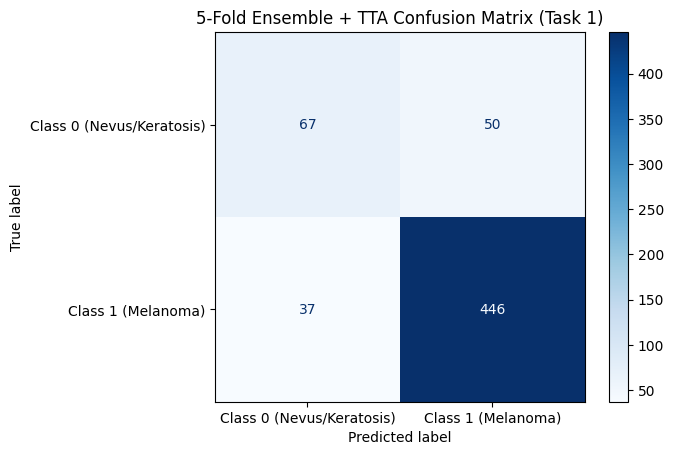

   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.644231   0.899194    0.855  0.771712     0.849476      0.862452
   Recall   0.572650   0.923395           0.748023        0.855              
 F1-Score   0.606335   0.911134           0.758734     0.851698              
  Support 117.000000 483.000000                                              


In [ ]:
# 8. Completely Independent Test-Time Augmentation (TTA) 5-Fold Ensemble Evaluation (Task 1)
# Standalone Cell: Loads saved fold checkpoints directly from Google Drive without relying on Cell 7 variables.

import os, torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Resolve Dataset & Checkpoint Paths
TEST_DIR = '/content/dataset/task1/test'
if not os.path.exists(TEST_DIR):
    TEST_DIR = 'dataset/task1/test'
if not os.path.exists(TEST_DIR):
    TEST_DIR = '/content/drive/MyDrive/MSc AI/dissertation/dataset/task1/test'

drive_path = '/content/drive/MyDrive/MSc AI/dissertation'
SAVE_DIR = os.path.join(drive_path, 'saved_models') if os.path.exists(drive_path) else './saved_models'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# 2. Prepare Independent Test DataLoader
test_transform = get_transforms(augment=False, dim=getattr(CONFIG, 'HEIGHT', 224))
test_data = ImageFolder(root=TEST_DIR, transform=test_transform)
num_workers = getattr(CONFIG, 'NUM_WORKERS', 4)
pin_mem = getattr(CONFIG, 'PIN_MEMORY', True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=pin_mem)

print(f"Loaded Test Dataset from {TEST_DIR} ({len(test_data)} samples)")
print(f"Loading fold checkpoints from: {SAVE_DIR}")

# 3. Run Standalone TTA Across All 5 Fold Models
all_fold_tta_probs = []
all_targets = []
loaded_folds = 0
num_folds = getattr(CONFIG, 'FOLDS', 5)

for fold in range(num_folds):
    checkpoint_path = os.path.join(SAVE_DIR, f'model-fold-{fold+1}.pt')
    if os.path.exists(checkpoint_path):
        print(f"  [+] Loading Fold {fold+1} Checkpoint: {checkpoint_path}")
        model = build_model(getattr(CONFIG, 'HEIGHT', 224)).to(device)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        fold_probs = []
        targets = []
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=True)

                # 4 TTA Image Views: Original, Horizontal Flip, Vertical Flip, 180 Rotation
                img_orig = images
                img_hflip = torch.flip(images, dims=[3])
                img_vflip = torch.flip(images, dims=[2])
                img_rot180 = torch.rot90(images, k=2, dims=[2, 3])

                if device.type == 'cuda':
                    with torch.cuda.amp.autocast(dtype=amp_dtype):
                        out_orig = torch.sigmoid(model(img_orig)).detach().cpu().float().numpy().flatten()
                        out_hflip = torch.sigmoid(model(img_hflip)).detach().cpu().float().numpy().flatten()
                        out_vflip = torch.sigmoid(model(img_vflip)).detach().cpu().float().numpy().flatten()
                        out_rot180 = torch.sigmoid(model(img_rot180)).detach().cpu().float().numpy().flatten()
                else:
                    out_orig = torch.sigmoid(model(img_orig)).detach().cpu().float().numpy().flatten()
                    out_hflip = torch.sigmoid(model(img_hflip)).detach().cpu().float().numpy().flatten()
                    out_vflip = torch.sigmoid(model(img_vflip)).detach().cpu().float().numpy().flatten()
                    out_rot180 = torch.sigmoid(model(img_rot180)).detach().cpu().float().numpy().flatten()

                # Average predicted probabilities across 4 TTA views
                batch_tta_probs = (out_orig + out_hflip + out_vflip + out_rot180) / 4.0
                fold_probs.extend(batch_tta_probs)

                if len(all_targets) < len(test_data):
                    targets.extend(labels.cpu().float().numpy().flatten())

        all_fold_tta_probs.append(fold_probs)
        if len(all_targets) == 0:
            all_targets = targets
        loaded_folds += 1

if loaded_folds > 0:
    # Ensemble predictions across all loaded fold models
    ensemble_tta_preds = np.mean(all_fold_tta_probs, axis=0)
    y_test = np.array(all_targets)

    print(f"\n=================== 5-FOLD ENSEMBLE + TTA EVALUATION (TASK 1) ===================")
    roc = roc_auc_score(y_test, ensemble_tta_preds)
    print(f"TTA Ensemble ROC AUC Score: {roc:.6f}")

    predicted_labels = (ensemble_tta_preds >= 0.5).astype(int)
    report = classification_report(y_test, predicted_labels, target_names=['Class 0', 'Class 1'], output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, predicted_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0 (Nevus/Keratosis)', 'Class 1 (Melanoma)'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("5-Fold Ensemble + TTA Confusion Matrix (Task 1)")
    plt.show()

    class_0 = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_1 = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    metrics_data = {
        'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
        'Class 0': [class_0['precision'], class_0['recall'], class_0['f1-score'], class_0['support']],
        'Class 1': [class_1['precision'], class_1['recall'], class_1['f1-score'], class_1['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }
    df_metrics = pd.DataFrame(metrics_data)
    print(df_metrics.to_string(index=False))
else:
    print(f"No checkpoint files found in {SAVE_DIR}. Please run training first.")
